# ETTm1 Forecasting 
## LSTM-Seq2Seq (Encoder-Decoder) | TCN



## Imports

In [82]:
import numpy as np
import pandas as pd
import math, time, os, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import weight_norm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.seasonal import STL
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Data Pipeline

## 1.1Load data

In [83]:
torch.manual_seed(42); np.random.seed(42)
df = pd.read_csv('data\\ETTm1.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
print(f'Columns: {df.columns.tolist()}')
print(f'Shape:   {df.shape}')

Columns: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
Shape:   (69680, 7)


In [84]:
df.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 00:15:00,5.760,2.076,1.492,0.426,4.264,1.401,30.459999
2016-07-01 00:30:00,5.760,1.942,1.492,0.391,4.234,1.310,30.038000
2016-07-01 00:45:00,5.760,1.942,1.492,0.426,4.234,1.310,27.013000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001


In [85]:
print(f"So luong mau: {len(df)}")
print(f"Khoang thoi gian: {df.index[0]} -> {df.index[-1]}")
print(f"Tan suat: 15 phut")
print(f"So luong features: {len(df.columns)}")
df.describe().round(2)

So luong mau: 69680
Khoang thoi gian: 2016-07-01 00:00:00 -> 2018-06-26 19:45:00
Tan suat: 15 phut
So luong features: 7


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,69680.00,69680.00,69680.00,69680.00,69680.00,69680.00,69680.00
mean,7.41,2.26,4.32,0.90,3.08,0.86,13.32
std,7.08,2.04,6.83,1.81,1.17,0.60,8.56
min,-23.24,-5.69,-26.37,-6.04,-1.19,-1.37,-4.22
25%,5.83,0.80,3.31,-0.28,2.32,0.67,6.96
50%,8.84,2.21,6.01,0.96,2.83,0.98,11.40
75%,11.79,3.68,8.64,2.20,3.65,1.22,18.08
max,24.18,10.31,18.09,7.85,8.50,3.05,46.01


### 1.2 Trực quan hóa dữ liệu 

### 1.2.1 Trực quan hóa biến theo thời gian

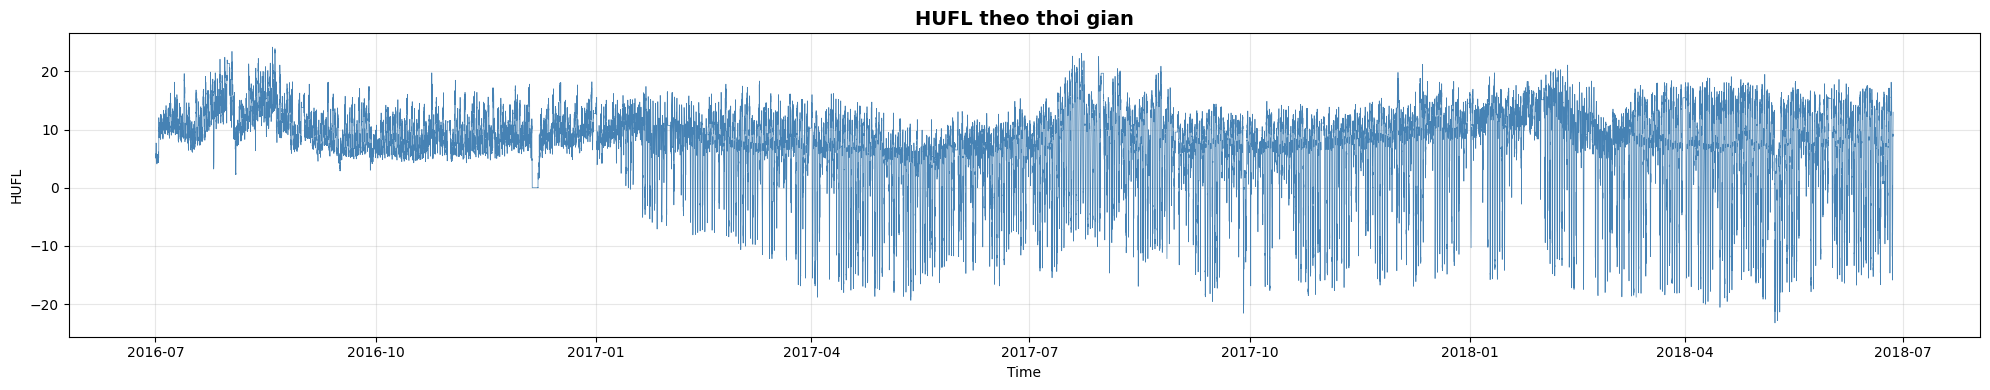

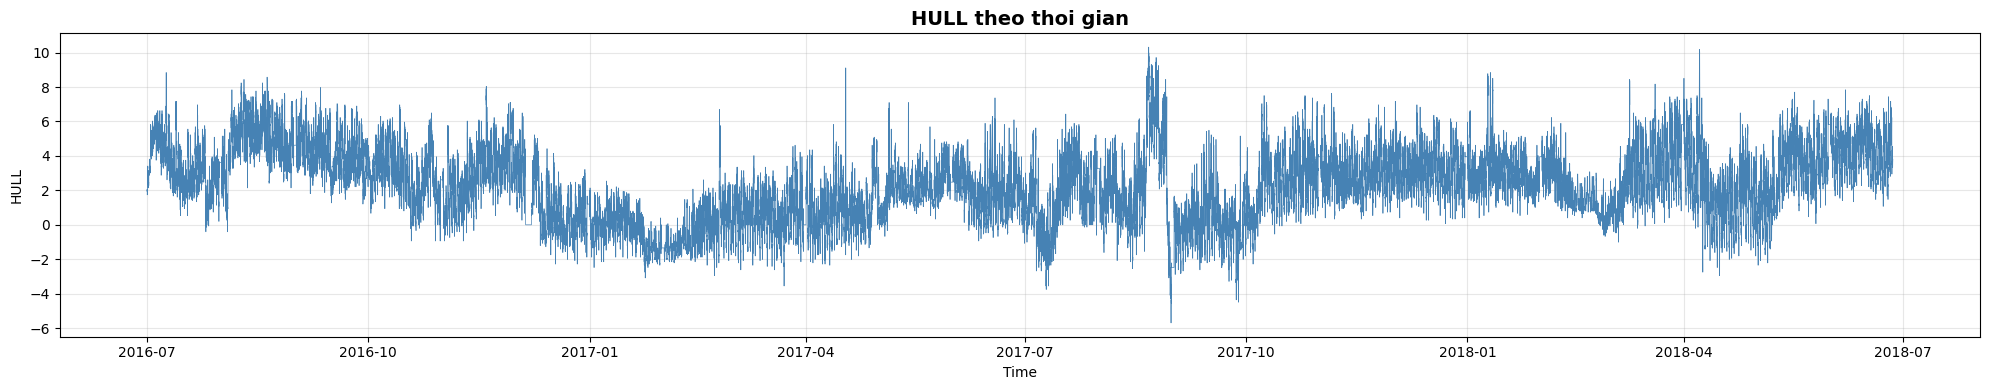

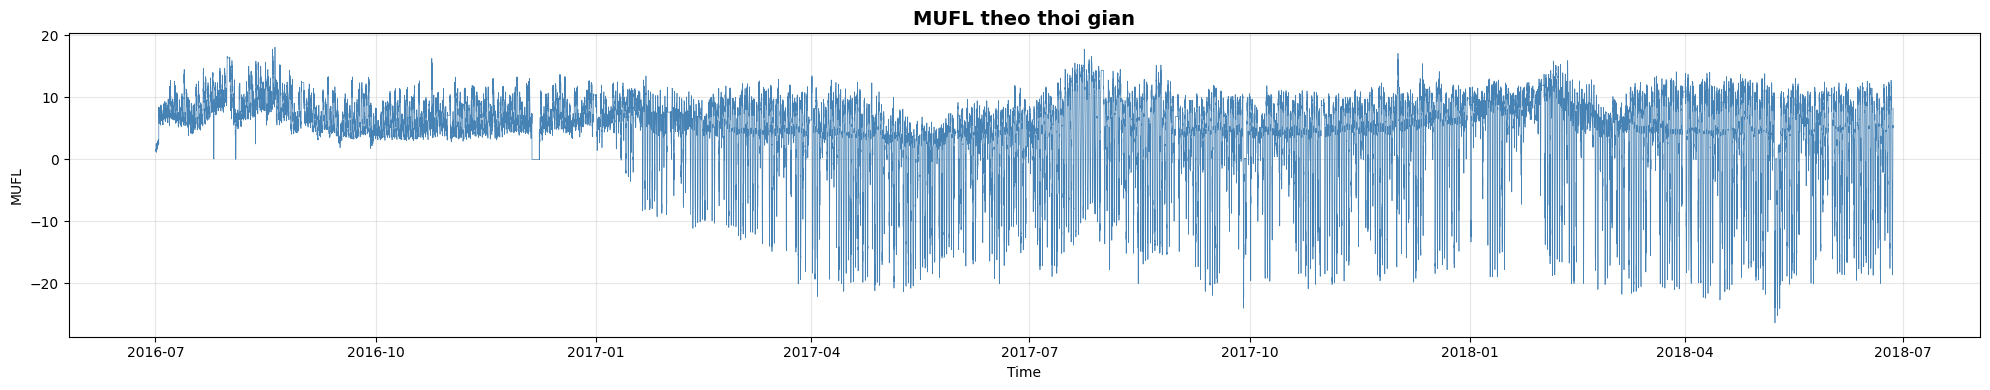

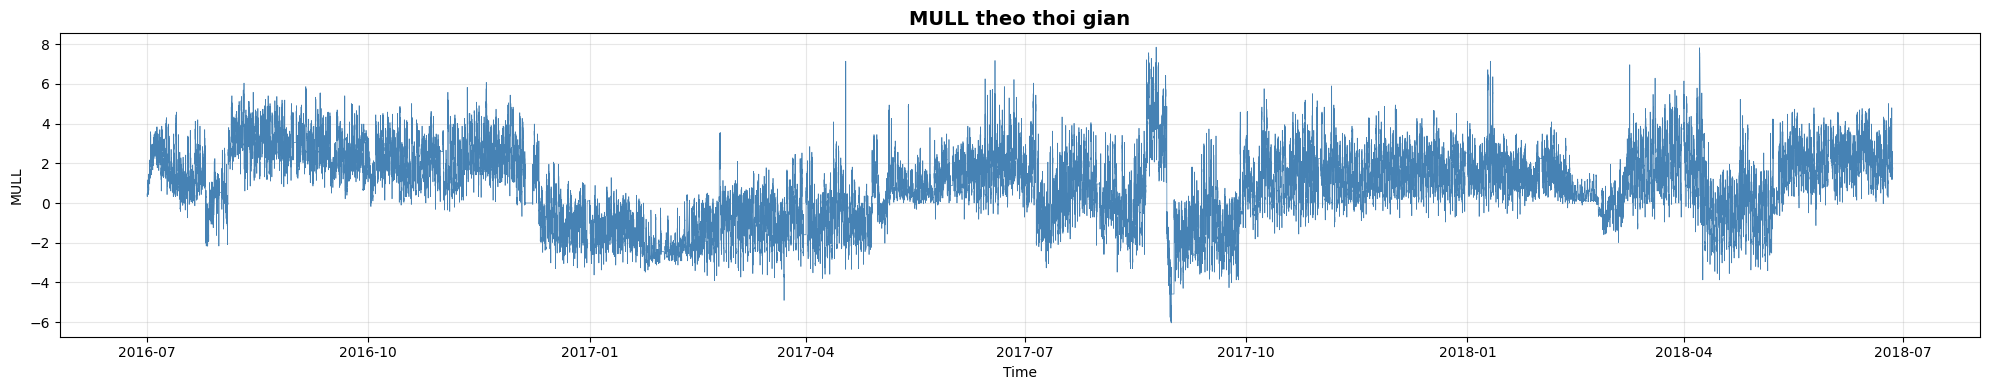

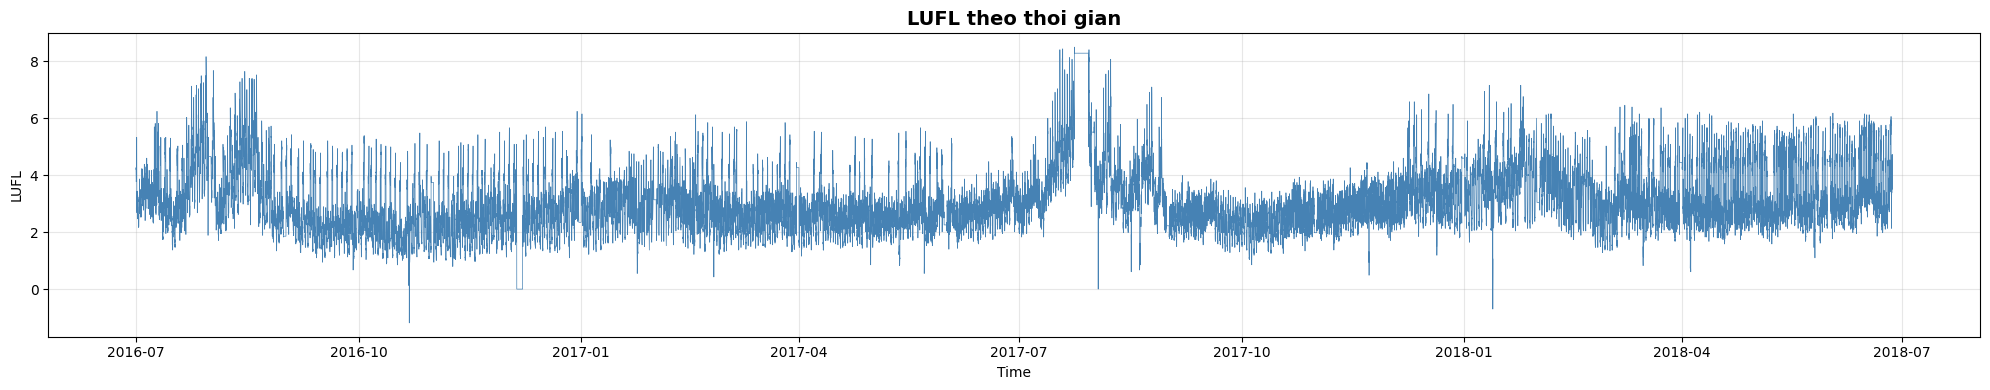

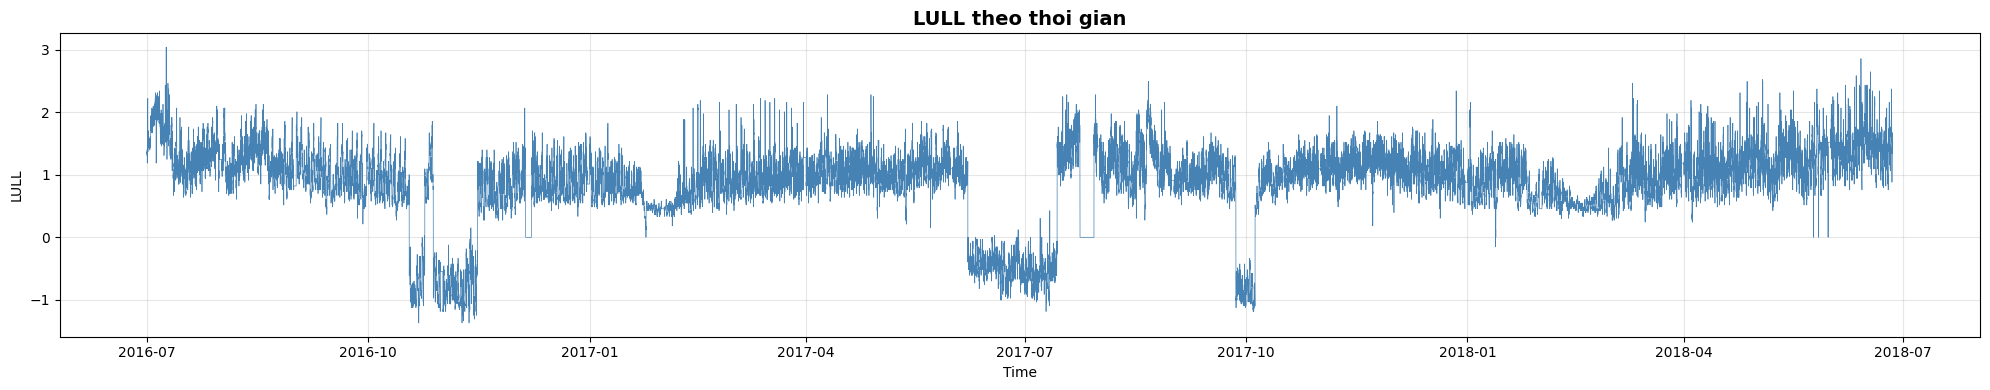

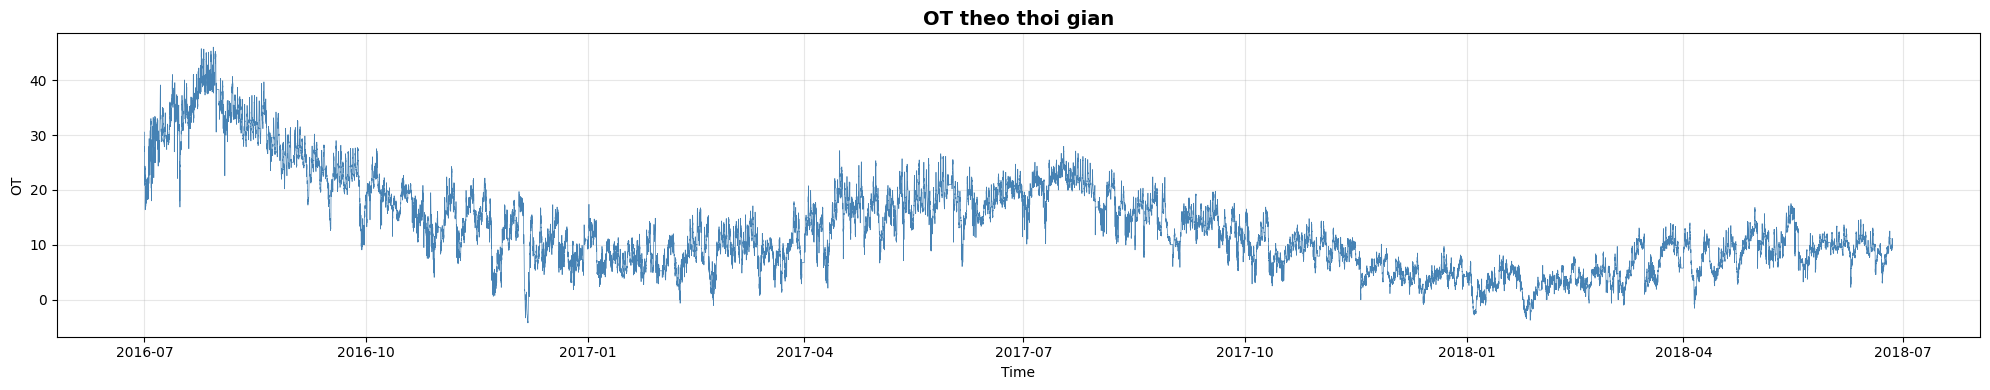

In [86]:
for col in df.columns:
    fig, ax = plt.subplots(figsize=(20, 4))
    ax.plot(df.index, df[col], linewidth=0.5, color='steelblue')
    ax.set_title(f'{col} theo thoi gian', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### 1.2.2 Biểu đồ phân phối theo từng biến

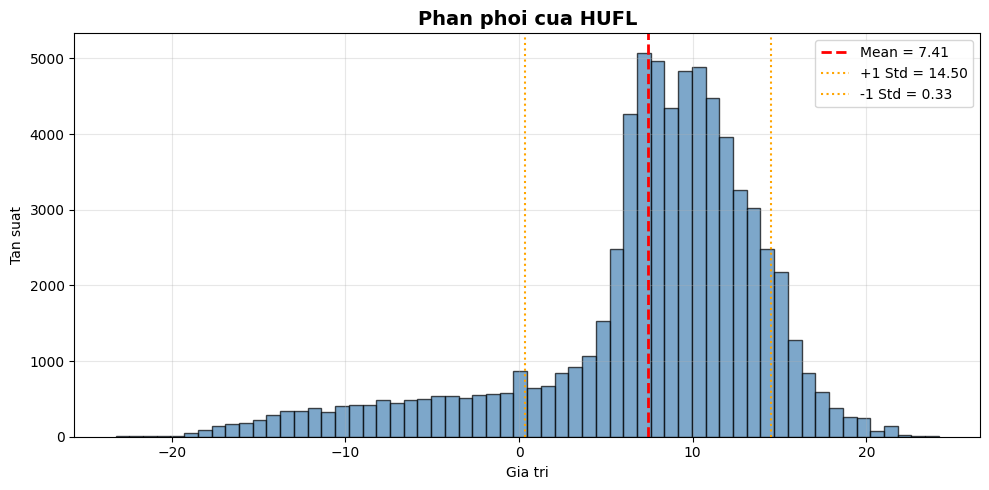

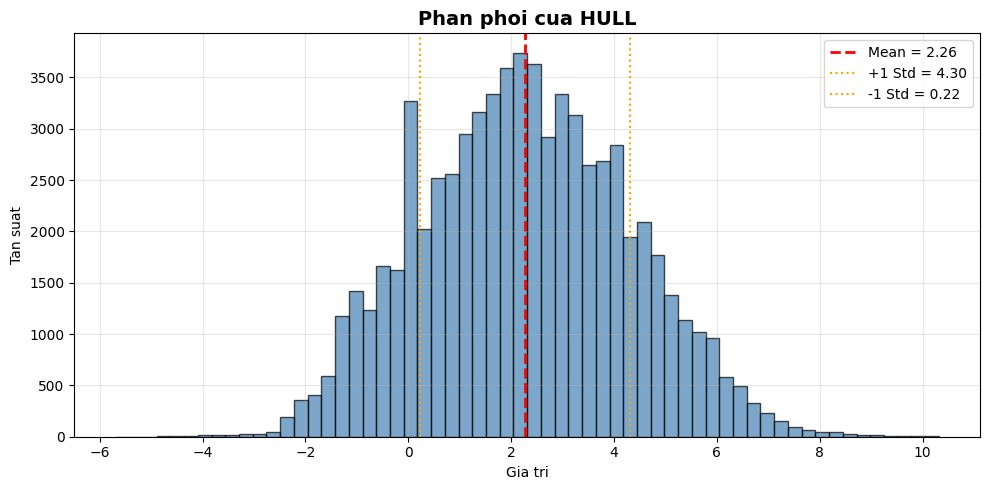

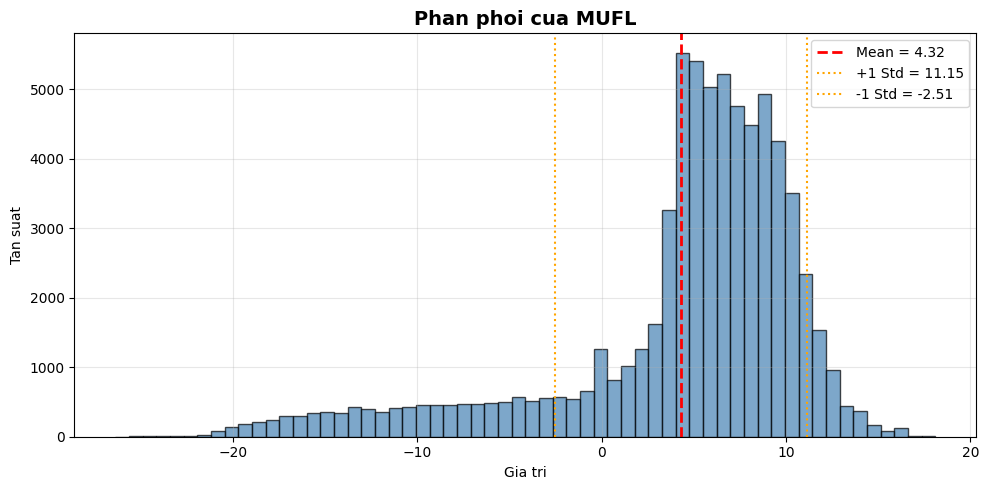

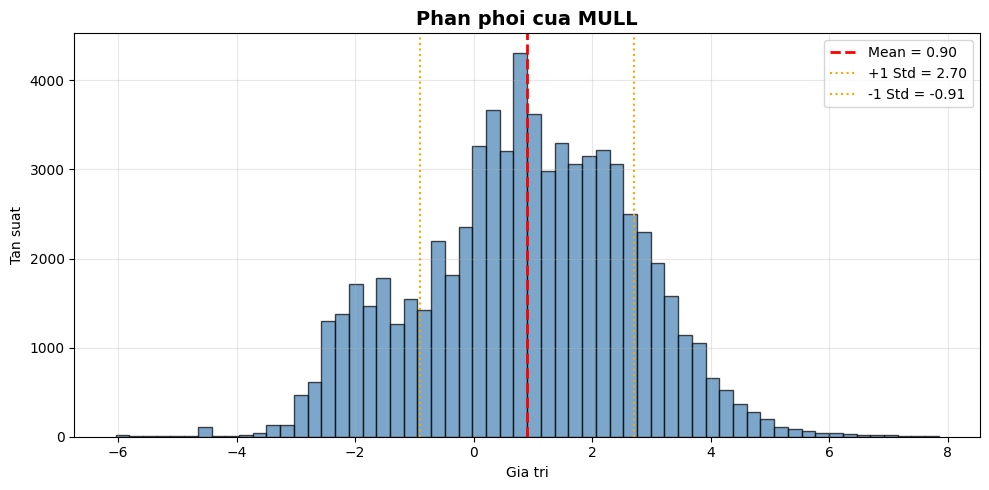

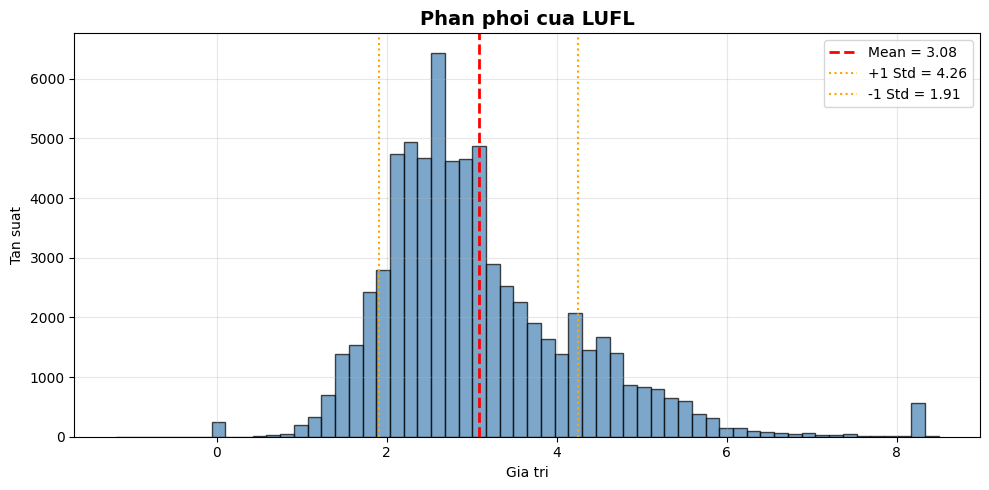

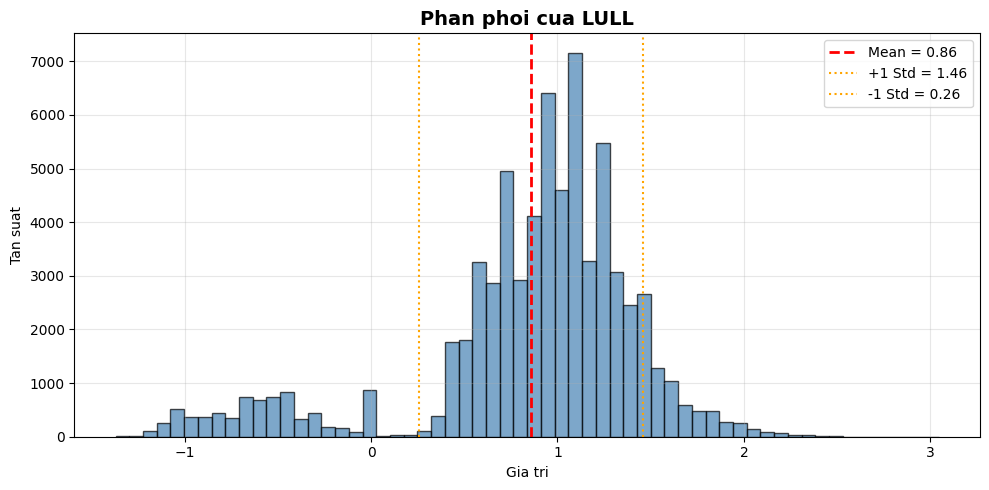

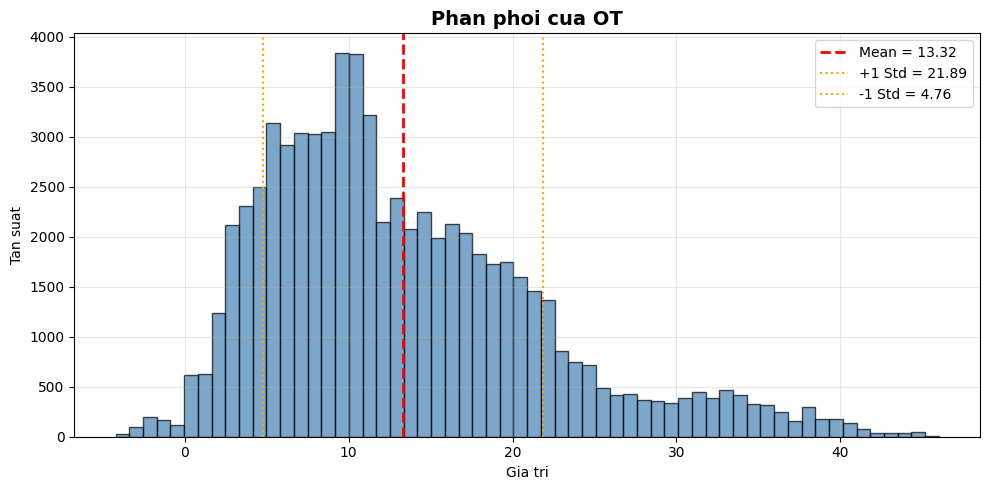

In [87]:
for col in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(df[col], bins=60, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'Phan phoi cua {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Gia tri')
    ax.set_ylabel('Tan suat')
    ax.grid(True, alpha=0.3)

    # Them thong ke
    mean_val = df[col].mean()
    std_val = df[col].std()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
    ax.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5, label=f'+1 Std = {mean_val+std_val:.2f}')
    ax.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5, label=f'-1 Std = {mean_val-std_val:.2f}')
    ax.legend()

    plt.tight_layout()
    plt.show()

## 1.3 Ma trận tương quan

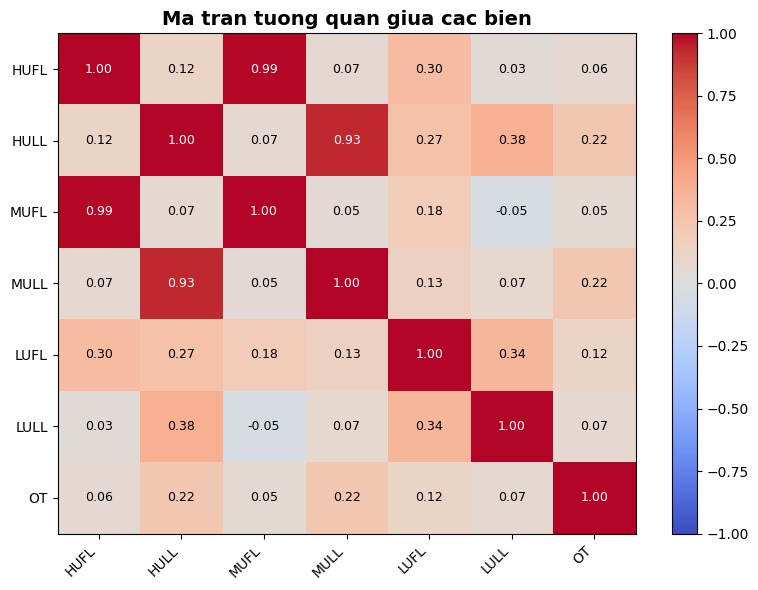

In [88]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black', fontsize=9)
fig.colorbar(im)
ax.set_title('Ma tran tuong quan giua cac bien', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [89]:
# Drop các cột có tính tương quan cao
for col in ['MUFL', 'MULL']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [90]:
stl = STL(df['OT'], period=96)
res = stl.fit()
df['trend'] = res.trend
df['seasonal'] = res.seasonal
df['residual'] = res.resid

print('STL decomposition added')

STL decomposition added


## 1.5 Set Basic Hyperparameters

In [91]:
n          = len(df)
train_size = int(n * 0.6)
val_size   = int(n * 0.2)

seq_len    = 336
label_len  = 48
pred_len   = 24
batch_size = 64

# Train / Val / Test
train_df = df.iloc[:train_size].copy()
val_df   = df.iloc[train_size:train_size + val_size].copy()
test_df  = df.iloc[train_size + val_size:].copy()

## 1.6 STL Residual

In [92]:
# # stl = STL(df['OT'], period=96)
# # res = stl.fit()
# # df['trend'] = res.trend
# # df['seasonal'] = res.seasonal
# # df['residual'] = res.resid

# # =============================================
# # STEP 1: Fit STL chỉ trên train
# # =============================================
# period = 96  # ETTm1: 15-phút × 96 = 1 ngày | ETTh1: dùng 24
# stl = STL(train_df["OT"], period=period)
# res = stl.fit()

# train_df["trend"]    = res.trend.values
# train_df["seasonal"] = res.seasonal.values
# train_df["residual"] = res.resid.values

# # =============================================
# # STEP 2: Extract pattern cố định từ train
# # =============================================

# # Seasonal: lấy 1 chu kỳ đại diện (mean của từng vị trí trong chu kỳ)
# seasonal_pattern = np.array([
#     res.seasonal[i::period].mean()
#     for i in range(period)
# ])  # shape: (period,) — 1 ngày điển hình

# def apply_seasonal(df, pattern):
#     """Tile seasonal pattern theo đúng vị trí giờ trong ngày"""
#     n = len(df)
#     # Căn theo vị trí trong ngày thực tế để không bị lệch pha
#     start_offset = (df.index[0].hour * 4 + df.index[0].minute // 15) % period
#     idx = [(start_offset + i) % period for i in range(n)]
#     return np.array([pattern[i] for i in idx])

# # Trend: rolling mean của OT (chỉ nhìn quá khứ → không leakage)
# def apply_trend(df, window=96):
#     return df["OT"].rolling(window=window, min_periods=1).mean().values

# # =============================================
# # STEP 3: Apply cho val và test
# # =============================================
# for split_df in [val_df, test_df]:
#     split_df["trend"]    = apply_trend(split_df, window=period)
#     split_df["seasonal"] = apply_seasonal(split_df, seasonal_pattern)
#     split_df["residual"] = (split_df["OT"]
#                             - split_df["trend"]
#                             - split_df["seasonal"]).values
# print('STL decomposition added')

## 1.7 Add Time Feature

In [93]:
def add_time_features(dataframe):
    idx = dataframe.index
    t_intra = idx.hour * 4 + idx.minute // 15
    dataframe['time_sin'] = np.sin(2 * np.pi * t_intra / 96)
    dataframe['time_cos'] = np.cos(2 * np.pi * t_intra / 96)
    dataframe['day_sin']  = np.sin(2 * np.pi * idx.dayofweek / 7)
    dataframe['day_cos']  = np.cos(2 * np.pi * idx.dayofweek / 7)
    return dataframe

for _df in [train_df, val_df, test_df]:
    add_time_features(_df)

In [94]:
target_col = 'OT'
print(f'Columns: {train_df.columns.tolist()}')
print(f'Shape:   {train_df.shape}')

Columns: ['HUFL', 'HULL', 'LUFL', 'LULL', 'OT', 'trend', 'seasonal', 'residual', 'time_sin', 'time_cos', 'day_sin', 'day_cos']
Shape:   (41808, 12)


# 1.8 Features definition

In [95]:
N_COVARIATE  = 4
target_index = train_df.columns.get_loc(target_col)
n_features   = len(train_df.columns)
print(f'Features count: {n_features}')

Features count: 12


## 1.9 Data scale and function for cal metric

In [96]:
# ═══════════════════════════════════════════════════════════════
# DATA PIPELINE (verified correct)
# ═══════════════════════════════════════════════════════════════
# Scaler fit ONLY on train
scaler       = StandardScaler()
train_scaled = scaler.fit_transform(train_df.values)
val_scaled   = scaler.transform(val_df.values)
test_scaled  = scaler.transform(test_df.values)

print(f'target_index = {target_index}, n_features = {n_features}')
print(f'Scaler mean[OT]={scaler.mean_[target_index]:.2f}, scale[OT]={scaler.scale_[target_index]:.2f}')
print(f'Train scaled stats: mean={train_scaled[:,target_index].mean():.4f}, std={train_scaled[:,target_index].std():.4f}')

def inverse_target(x, scaler, idx):
    return x * scaler.scale_[idx] + scaler.mean_[idx]

def calc_metrics(y_pred, y_true):
    mse  = np.mean((y_pred - y_true) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_pred - y_true))
    denom = (np.abs(y_pred) + np.abs(y_true)) / 2.0
    denom = np.maximum(denom, 1.0)
    smape = np.mean(np.abs(y_pred - y_true) / denom) * 100
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'sMAPE%': smape}

print('Data pipeline ready.')

target_index = 4, n_features = 12
Scaler mean[OT]=17.29, scale[OT]=8.51
Train scaled stats: mean=0.0000, std=1.0000
Data pipeline ready.


# 1.10 Xử lý Time freeze (không hiệu quả)

In [97]:
# # tổng thay đổi mỗi dòng
# diff_sum_train = train_df.diff().abs().sum(axis=1)
# diff_sum_val = val_df.diff().abs().sum(axis=1)
# diff_sum_test = test_df.diff().abs().sum(axis=1)

# # dòng không thay đổi
# is_constant_train = diff_sum_train == 0
# is_constant_val = diff_sum_val == 0
# is_constant_test = diff_sum_test == 0

# # phát hiện block >= 6 giờ
# window = 6
# freeze_block_train = is_constant_train.rolling(window).sum() >= window
# freeze_block_val = is_constant_val.rolling(window).sum() >= window
# freeze_block_test = is_constant_test.rolling(window).sum() >= window

# train_df.loc[freeze_block_train] = np.nan
# val_df.loc[freeze_block_val] = np.nan
# test_df.loc[freeze_block_test] = np.nan

# train_df.interpolate(method="time", inplace=True)
# val_df.interpolate(method="time", inplace=True)
# test_df.interpolate(method="time", inplace=True)

# 1.11 Xử lý oulier (không hiệu quả)

In [98]:
# lower  = Q1 - 1.5*IQR 
# upper  = Q3 + 1.5*IQR
# for d in [df_train, df_val, df_test]:
#     d['OT'] = d['OT'].clip(lower, upper)

## 1.12 Dataset & DataLoaders

In [99]:
# ═══════════════════════════════════════════════════════════════
# DATASET (no augmentation – keep it clean for debugging)
# ═══════════════════════════════════════════════════════════════
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, label_len, pred_len):
        self.data = data
        self.seq_len   = seq_len
        self.label_len = label_len
        self.pred_len  = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        s_end   = idx + self.seq_len
        r_begin = s_end - self.label_len
        r_end   = r_begin + self.label_len + self.pred_len
        seq_x = torch.tensor(self.data[idx:s_end], dtype=torch.float32)
        seq_y = torch.tensor(self.data[r_begin:r_end], dtype=torch.float32)
        return seq_x, seq_y

train_ds = TimeSeriesDataset(train_scaled, seq_len, label_len, pred_len)
val_ds   = TimeSeriesDataset(val_scaled,   seq_len, label_len, pred_len)
test_ds  = TimeSeriesDataset(test_scaled,  seq_len, label_len, pred_len)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

# ── Sanity check: verify alignment ──
Xb, Yb = next(iter(train_loader))
print(f'X shape: {Xb.shape}  (batch, seq_len, features)')
print(f'Y shape: {Yb.shape}  (batch, label_len+pred_len, features)')
y_target = Yb[:, -pred_len:, target_index]
print(f'Target shape: {y_target.shape}  (batch, pred_len)')
print(f'Target range: [{y_target.min():.3f}, {y_target.max():.3f}]  (should be ~[-3, 3] for scaled data)')
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

X shape: torch.Size([64, 336, 12])  (batch, seq_len, features)
Y shape: torch.Size([64, 72, 12])  (batch, label_len+pred_len, features)
Target shape: torch.Size([64, 24])  (batch, pred_len)
Target range: [-1.940, 2.730]  (should be ~[-3, 3] for scaled data)
Train batches: 647 | Val: 213 | Test: 213


## 2. Training Utilities

In [100]:
EPOCHS   = 100
PATIENCE = 25
NOISE_STD = 0.02
TREND_LAMBDA = 0.3

def trend_loss_fn(pred, true):
    diff_pred = pred[:, 1:] - pred[:, :-1]
    diff_true = true[:, 1:] - true[:, :-1]
    return torch.nn.functional.mse_loss(diff_pred, diff_true)

def train_model(model, train_loader, val_loader, optimizer, scheduler,
                epochs, patience, model_name, save_path, pred_fn, device,
                use_noise=True, trend_lambda=TREND_LAMBDA):
    criterion = nn.MSELoss()
    train_hist, val_hist = [], []
    best_val = float('inf')
    best_epoch = 0
    counter = 0
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for Xb, Yb in train_loader:
            Xb, Yb = Xb.to(device), Yb.to(device)
            y_true = Yb[:, -pred_len:, target_index]
            if use_noise and NOISE_STD > 0:
                Xb = Xb + torch.randn_like(Xb) * NOISE_STD
            optimizer.zero_grad()
            out = pred_fn(model, Xb, Yb)
            mse_loss = criterion(out, y_true)
            t_loss = trend_loss_fn(out, y_true)
            loss = mse_loss + trend_lambda * t_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())
        model.eval()
        val_losses = []
        with torch.no_grad():
            for Xv, Yv in val_loader:
                Xv, Yv = Xv.to(device), Yv.to(device)
                y_val = Yv[:, -pred_len:, target_index]
                out_v = pred_fn(model, Xv, Yv)
                vloss = criterion(out_v, y_val) + trend_lambda * trend_loss_fn(out_v, y_val)
                val_losses.append(vloss.item())
        tr = np.mean(train_losses); vl = np.mean(val_losses)
        train_hist.append(tr); val_hist.append(vl)
        scheduler.step()
        lr = optimizer.param_groups[0]['lr']
        ratio = vl / max(tr, 1e-9)
        print(f'[{model_name}] Ep {epoch+1:03d}/{epochs} | Train: {tr:.6f} | Val: {vl:.6f} | V/T: {ratio:.2f} | LR: {lr:.2e}')
        if vl < best_val:
            best_val = vl; best_epoch = epoch + 1
            torch.save(model.state_dict(), save_path); counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f'  >> Early Stop ({model_name}) at epoch {epoch+1}'); break
    elapsed = time.time() - t0
    print(f'Best Val ({model_name}): {best_val:.6f} at epoch {best_epoch} | {elapsed:.0f}s')
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return {'train': train_hist, 'val': val_hist, 'best_val': best_val, 'best_epoch': best_epoch, 'time': elapsed}

print('Training utilities ready (v7).')


Training utilities ready (v7).


## 3. LSTM-Seq2Seq (Encoder-Decoder Baseline)


### Model

In [ ]:
# ═══════════════════════════════════════════════════════════════
# MODEL 1: LSTM-Seq2Seq (Encoder-Decoder)
# ═══════════════════════════════════════════════════════════════
torch.manual_seed(42); np.random.seed(42)

class LSTMSeq2Seq(nn.Module):
    def __init__(self, input_dim, hidden_size=128, num_layers=2,
                 pred_len=24, dropout=0.3, target_index=0):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.pred_len = pred_len
        self.target_index = target_index

        # Encoder: processes the entire input sequence
        self.encoder = nn.LSTM(input_dim, hidden_size, num_layers,
                               batch_first=True,
                               dropout=dropout if num_layers > 1 else 0)

        # Decoder: takes previous prediction (1-dim) and generates next step
        self.decoder = nn.LSTM(1, hidden_size, num_layers,
                               batch_first=True,
                               dropout=dropout if num_layers > 1 else 0)

        # Output projection: hidden -> 1 scalar prediction per step
        self.fc_out = nn.Linear(hidden_size, 1)

    def forward(self, x, y_teacher=None, teacher_forcing_ratio=0.5):
        batch_size = x.size(0)

        # ── Encoder ──
        _, (h, c) = self.encoder(x)  # h, c: (num_layers, B, hidden)

        # ── Decoder ──
        # First decoder input: last known target value from encoder input
        decoder_input = x[:, -1, self.target_index].unsqueeze(1).unsqueeze(2)  # (B, 1, 1)

        outputs = []
        for t in range(self.pred_len):
            dec_out, (h, c) = self.decoder(decoder_input, (h, c))
            pred_t = self.fc_out(dec_out.squeeze(1))  # (B, 1)
            outputs.append(pred_t)

            # Teacher forcing: use ground truth or own prediction
            if y_teacher is not None and self.training:
                use_teacher = (torch.rand(1).item() < teacher_forcing_ratio)
                if use_teacher:
                    decoder_input = y_teacher[:, t].unsqueeze(1).unsqueeze(2)  # (B, 1, 1)
                else:
                    decoder_input = pred_t.unsqueeze(1)  # (B, 1, 1)
            else:
                decoder_input = pred_t.unsqueeze(1)  # (B, 1, 1)

        return torch.cat(outputs, dim=1)  # (B, pred_len)
def seq2seq_pred_fn(model, Xb, Yb):
    y_teacher = Yb[:, -pred_len:, target_index]  # ground truth for teacher forcing
    return model(Xb, y_teacher=y_teacher)

### Hyperparameter

In [ ]:
Seq2Seq_LR = 5E-4
Seq2Seq_WEIGHT = 1E-3
Seq2Seq_ETA_MIN = 1E-6
Seq2Seq_DROP_OUT = 0.3
Seq2Seq_NUM_LAYERS = 2
Seq2Seq_HIDDEN_SIZE = 128

### Khởi tạo model

In [ ]:
seq2seq_model = LSTMSeq2Seq(n_features, hidden_size=Seq2Seq_HIDDEN_SIZE, num_layers=Seq2Seq_NUM_LAYERS,
                             pred_len=pred_len, dropout=Seq2Seq_DROP_OUT,
                             target_index=target_index).to(device)
print(f'Seq2Seq params: {sum(p.numel() for p in seq2seq_model.parameters() if p.requires_grad):,}')

seq2seq_opt = torch.optim.AdamW(seq2seq_model.parameters(), lr=Seq2Seq_LR, weight_decay=Seq2Seq_WEIGHT)
seq2seq_sched = torch.optim.lr_scheduler.CosineAnnealingLR(seq2seq_opt, T_max=EPOCHS, eta_min=Seq2Seq_ETA_MIN)

### Train

In [ ]:
seq2seq_results = train_model(
    seq2seq_model, train_loader, val_loader, seq2seq_opt, seq2seq_sched,
    epochs=EPOCHS, patience=PATIENCE, model_name='Seq2Seq', save_path='best_seq2seq_v9.pth',
    pred_fn=seq2seq_pred_fn, device=device)

Seq2Seq params: 404,097


[Seq2Seq] Ep 001/100 | Train: 0.052084 | Val: 0.013385 | V/T: 0.26 | LR: 5.00e-04
[Seq2Seq] Ep 002/100 | Train: 0.015174 | Val: 0.013081 | V/T: 0.86 | LR: 5.00e-04
[Seq2Seq] Ep 003/100 | Train: 0.013034 | Val: 0.015784 | V/T: 1.21 | LR: 4.99e-04
[Seq2Seq] Ep 004/100 | Train: 0.011640 | Val: 0.012753 | V/T: 1.10 | LR: 4.98e-04
[Seq2Seq] Ep 005/100 | Train: 0.011084 | Val: 0.010077 | V/T: 0.91 | LR: 4.97e-04
[Seq2Seq] Ep 006/100 | Train: 0.009971 | Val: 0.010122 | V/T: 1.02 | LR: 4.96e-04
[Seq2Seq] Ep 007/100 | Train: 0.009692 | Val: 0.011364 | V/T: 1.17 | LR: 4.94e-04
[Seq2Seq] Ep 008/100 | Train: 0.009290 | Val: 0.017121 | V/T: 1.84 | LR: 4.92e-04
[Seq2Seq] Ep 009/100 | Train: 0.008746 | Val: 0.013472 | V/T: 1.54 | LR: 4.90e-04
[Seq2Seq] Ep 010/100 | Train: 0.008662 | Val: 0.014119 | V/T: 1.63 | LR: 4.88e-04
[Seq2Seq] Ep 011/100 | Train: 0.008319 | Val: 0.014153 | V/T: 1.70 | LR: 4.85e-04
[Seq2Seq] Ep 012/100 | Train: 0.008159 | Val: 0.016238 | V/T: 1.99 | LR: 4.82e-04
[Seq2Seq] Ep 013

## 4. TCN_v2 (No RevIN, Proper Receptive Field)



### Model

In [103]:
# ═══════════════════════════════════════════════════════════════
# MODEL 2: TCN_v2
# ═══════════════════════════════════════════════════════════════
torch.manual_seed(42); np.random.seed(42)

class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.norm1 = nn.LayerNorm(in_ch)
        self.norm2 = nn.LayerNorm(out_ch)
        self.conv1 = weight_norm(nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation))
        self.conv2 = weight_norm(nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad, dilation=dilation))
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.proj = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        r = x
        out = x.transpose(1, 2); out = self.norm1(out); out = out.transpose(1, 2)
        out = self.conv1(out)[:, :, :x.size(2)]
        out = self.act(out); out = self.dropout(out)
        out = out.transpose(1, 2); out = self.norm2(out); out = out.transpose(1, 2)
        out = self.conv2(out)[:, :, :x.size(2)]
        out = self.act(out); out = self.dropout(out)
        res = r if self.proj is None else self.proj(r)
        return self.act(out + res)

class TCN_v2(nn.Module):
    def __init__(self, input_dim, num_channels, kernel_size=5,
                 dropout=0.3, horizon=24, covariate_dim=4, target_index=0):
        super().__init__()
        self.target_index = target_index
        layers = []
        for i, out_ch in enumerate(num_channels):
            in_ch = input_dim if i == 0 else num_channels[i - 1]
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, 2**i, dropout))
        self.network = nn.Sequential(*layers)
        last_ch = num_channels[-1]
        self.cov_proj = nn.Linear(horizon * covariate_dim, 64)
        self.fc_head = nn.Sequential(
            nn.LayerNorm(last_ch + 64),
            nn.Linear(last_ch + 64, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, horizon))

    def forward(self, x, future_features=None):
        y = self.network(x.permute(0, 2, 1))
        last = y[:, :, -1]
        if future_features is not None:
            cov = future_features.reshape(future_features.size(0), -1)
            feat = torch.cat([last, self.cov_proj(cov)], dim=1)
        else:
            feat = torch.cat([last, torch.zeros(x.size(0), 64, device=x.device)], dim=1)
        pred = self.fc_head(feat)  # scaled
        return pred  # v7: direct prediction

def calc_rf(k, n):
    return 1 + 2 * (k - 1) * sum(2**i for i in range(n))
    
def tcn_pred_fn(model, Xb, Yb):
    f_cov = Yb[:, -pred_len:, -N_COVARIATE:]
    return model(Xb, future_features=f_cov)

### Hyperparameter

In [104]:
TCN_LR = 5E-4
TCN_WEIGHT = 1E-3
TCN_ETA_MIN = 1E-6
TCN_DROP_OUT = 0.3
TCN_KERNEL_SIZE = 7
TCN_CHANELS = [32, 64, 128, 128, 256]

num_channels_tcn = TCN_CHANELS
rf = calc_rf(TCN_KERNEL_SIZE, len(num_channels_tcn))
print(f'TCN RF: {rf} (>= {seq_len}: {rf >= seq_len})')

TCN RF: 373 (>= 336: True)


### Khởi tạo

In [105]:
tcn_model = TCN_v2(n_features, num_channels_tcn, kernel_size=TCN_KERNEL_SIZE, dropout=TCN_DROP_OUT,
                    horizon=pred_len, covariate_dim=N_COVARIATE,
                    target_index=target_index).to(device)
print(f'TCN params: {sum(p.numel() for p in tcn_model.parameters() if p.requires_grad):,}')

tcn_opt = torch.optim.AdamW(tcn_model.parameters(), lr=TCN_LR, weight_decay=TCN_WEIGHT)
tcn_sched = torch.optim.lr_scheduler.CosineAnnealingLR(tcn_opt, T_max=EPOCHS, eta_min=TCN_ETA_MIN)

TCN params: 1,241,680


In [ ]:
tcn_results = train_model(
    tcn_model, train_loader, val_loader, tcn_opt, tcn_sched,
    epochs=EPOCHS, patience=PATIENCE, model_name='TCN', save_path='best_tcn_v9.pth',
    pred_fn=tcn_pred_fn, device=device)

[TCN] Ep 001/100 | Train: 0.098602 | Val: 0.053121 | V/T: 0.54 | LR: 5.00e-04
[TCN] Ep 002/100 | Train: 0.037404 | Val: 0.045541 | V/T: 1.22 | LR: 5.00e-04
[TCN] Ep 003/100 | Train: 0.031198 | Val: 0.039029 | V/T: 1.25 | LR: 4.99e-04
[TCN] Ep 004/100 | Train: 0.027937 | Val: 0.043102 | V/T: 1.54 | LR: 4.98e-04
[TCN] Ep 005/100 | Train: 0.025450 | Val: 0.046221 | V/T: 1.82 | LR: 4.97e-04
[TCN] Ep 006/100 | Train: 0.024680 | Val: 0.040202 | V/T: 1.63 | LR: 4.96e-04
[TCN] Ep 007/100 | Train: 0.023252 | Val: 0.050760 | V/T: 2.18 | LR: 4.94e-04
[TCN] Ep 008/100 | Train: 0.022327 | Val: 0.051526 | V/T: 2.31 | LR: 4.92e-04
[TCN] Ep 009/100 | Train: 0.021677 | Val: 0.065851 | V/T: 3.04 | LR: 4.90e-04
[TCN] Ep 010/100 | Train: 0.020898 | Val: 0.045191 | V/T: 2.16 | LR: 4.88e-04
[TCN] Ep 011/100 | Train: 0.019828 | Val: 0.036746 | V/T: 1.85 | LR: 4.85e-04
[TCN] Ep 012/100 | Train: 0.019773 | Val: 0.055314 | V/T: 2.80 | LR: 4.82e-04
[TCN] Ep 013/100 | Train: 0.018817 | Val: 0.030111 | V/T: 1.60 |

## 6. Test Evaluation & Comparison

In [ ]:
# ═══════════════════════════════════════════════════════════════
# TEST EVALUATION (inverse-scaled → °C units)
# ═══════════════════════════════════════════════════════════════
def evaluate(model, loader, pred_fn):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, Yb in loader:
            Xb, Yb = Xb.to(device), Yb.to(device)
            y_true = Yb[:, -pred_len:, target_index]
            out = pred_fn(model, Xb, Yb)
            # Inverse transform to °C
            preds.append(inverse_target(out.cpu().numpy(), scaler, target_index))
            trues.append(inverse_target(y_true.cpu().numpy(), scaler, target_index))
    return np.concatenate(preds), np.concatenate(trues)
# Predictions
# --- Seq2Seq ---
s2s_checkpoint = torch.load(".../models/best_seq2seq_v9_last_checkpoint.pth", map_location=device, weights_only=False)
seq2seq_model.load_state_dict(s2s_checkpoint)
seq2seq_model.eval()

# --- TCN_v9 ---
tcn_checkpoint = torch.load("best_tcn_v9.pth", map_location=device, weights_only=False)
tcn_model.load_state_dict(tcn_checkpoint)
tcn_model.eval()

# Evaluate all models
seq2seq_preds, seq2seq_trues = evaluate(seq2seq_model, test_loader, seq2seq_pred_fn)
tcn_preds, tcn_trues = evaluate(tcn_model, test_loader, tcn_pred_fn)

seq2seq_m = calc_metrics(seq2seq_preds, seq2seq_trues)
tcn_m = calc_metrics(tcn_preds, tcn_trues)

# Debug: check prediction stats
for name, p, t in [('LSTM-Seq2Seq', seq2seq_preds, seq2seq_trues),
                     ('TCN', tcn_preds, tcn_trues)]:
    print(f'{name}: pred mean={p.mean():.2f} std={p.std():.2f} | true mean={t.mean():.2f} std={t.std():.2f}')

print()
print('=' * 75)
print(f'{"Metric":>10} | {"LSTM-Seq2Seq":>14} | {"TCN_v2":>14}')
print('-' * 75)
for k in ['MSE', 'RMSE', 'MAE', 'sMAPE%']:
    print(f'{k:>10} | {seq2seq_m[k]:>14.4f} | {tcn_m[k]:>14.4f}')
print(f'{"Best ep":>10} | {seq2seq_results["best_epoch"]:>14d} | {tcn_results["best_epoch"]:>14d}')
print(f'{"Time":>10} | {seq2seq_results["time"]:>13.0f}s | {tcn_results["time"]:>13.0f}s')
print(f'{"Val MSE":>10} | {seq2seq_results["best_val"]:>14.6f} | {tcn_results["best_val"]:>14.6f}')
print('=' * 75)

best_mse = min(seq2seq_m['MSE'], tcn_m['MSE'])
best_name = ['LSTM-Seq2Seq', 'TCN_v2'][[seq2seq_m['MSE'], tcn_m['MSE']].index(best_mse)]
print(f'\n🏆 Best model: {best_name} (Test MSE = {best_mse:.4f} °C²)')

LSTM-Seq2Seq: pred mean=7.98 std=3.39 | true mean=7.84 std=3.39
TCN: pred mean=8.38 std=3.31 | true mean=7.84 std=3.39

    Metric |   LSTM-Seq2Seq |         TCN_v2
---------------------------------------------------------------------------
       MSE |         1.2656 |         2.1248
      RMSE |         1.1250 |         1.4577
       MAE |         0.7852 |         1.0918
    sMAPE% |        13.6451 |        17.9306
   Best ep |              3 |              4
      Time |           999s |          1389s
   Val MSE |       0.018889 |       0.042994

🏆 Best model: LSTM-Seq2Seq (Test MSE = 1.2656 °C²)


## 7. Learning Curves

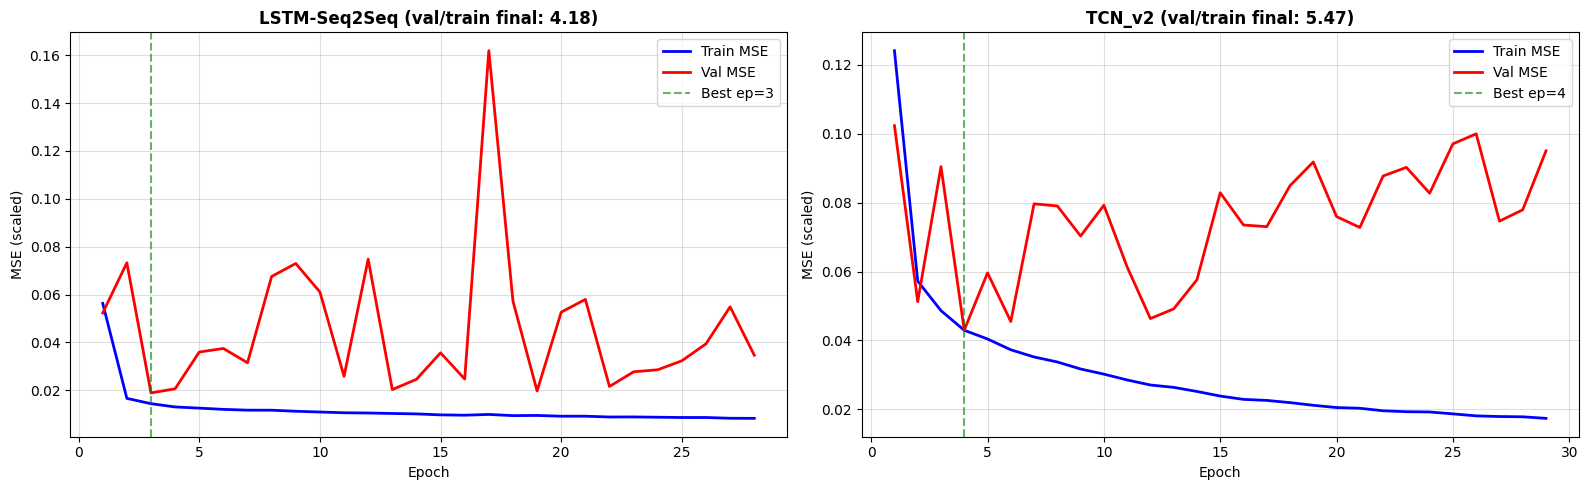

In [ ]:
# ═══════════════════════════════════════════════════════════════
# LEARNING CURVES
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, res, title in [
    (axes[0], seq2seq_results, 'LSTM-Seq2Seq'),
    (axes[1], tcn_results, 'TCN_v2')]:
    ep = range(1, len(res['train']) + 1)
    ax.plot(ep, res['train'], 'b-', label='Train MSE', linewidth=2)
    ax.plot(ep, res['val'],   'r-', label='Val MSE',   linewidth=2)
    ax.axvline(res['best_epoch'], color='green', linestyle='--', alpha=0.6,
               label=f'Best ep={res["best_epoch"]}')
    ax.set_title(f'{title} (val/train final: {res["val"][-1]/res["train"][-1]:.2f})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)')
    ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('.../results/learning_curves_v9.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Prediction Visualization

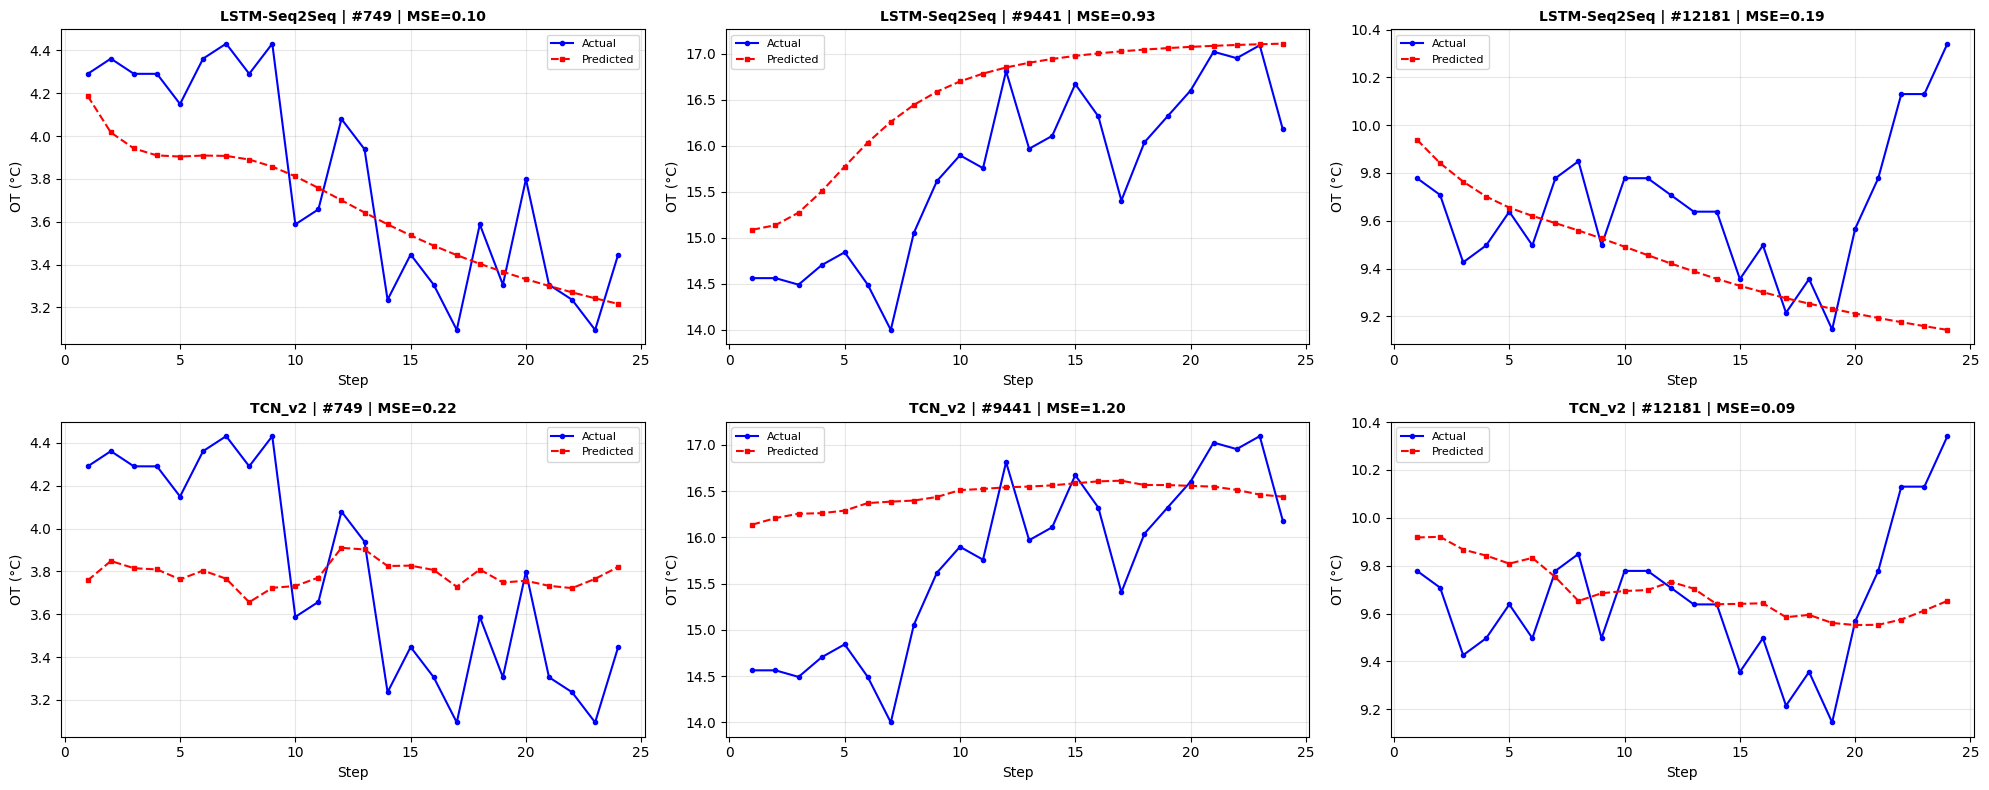

In [ ]:
# ═══════════════════════════════════════════════════════════════
# PREDICTIONS VS ACTUAL
# ═══════════════════════════════════════════════════════════════
np.random.seed(42)
sample_idx = sorted(np.random.choice(len(seq2seq_preds), 3, replace=False))

fig, axes = plt.subplots(2, 3, figsize=(20, 8))
models = [('LSTM-Seq2Seq', seq2seq_preds, seq2seq_trues),
          ('TCN_v2', tcn_preds, tcn_trues)]

for row, (name, preds, trues) in enumerate(models):
    for col, idx in enumerate(sample_idx):
        ax = axes[row, col]
        steps = range(1, pred_len + 1)
        ax.plot(steps, trues[idx], 'b-o', label='Actual', markersize=3, linewidth=1.5)
        ax.plot(steps, preds[idx], 'r--s', label='Predicted', markersize=3, linewidth=1.5)
        mse_i = np.mean((preds[idx] - trues[idx])**2)
        ax.set_title(f'{name} | #{idx} | MSE={mse_i:.2f}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Step'); ax.set_ylabel('OT (°C)')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('.../results/predictions_v9.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Bar Chart Comparison

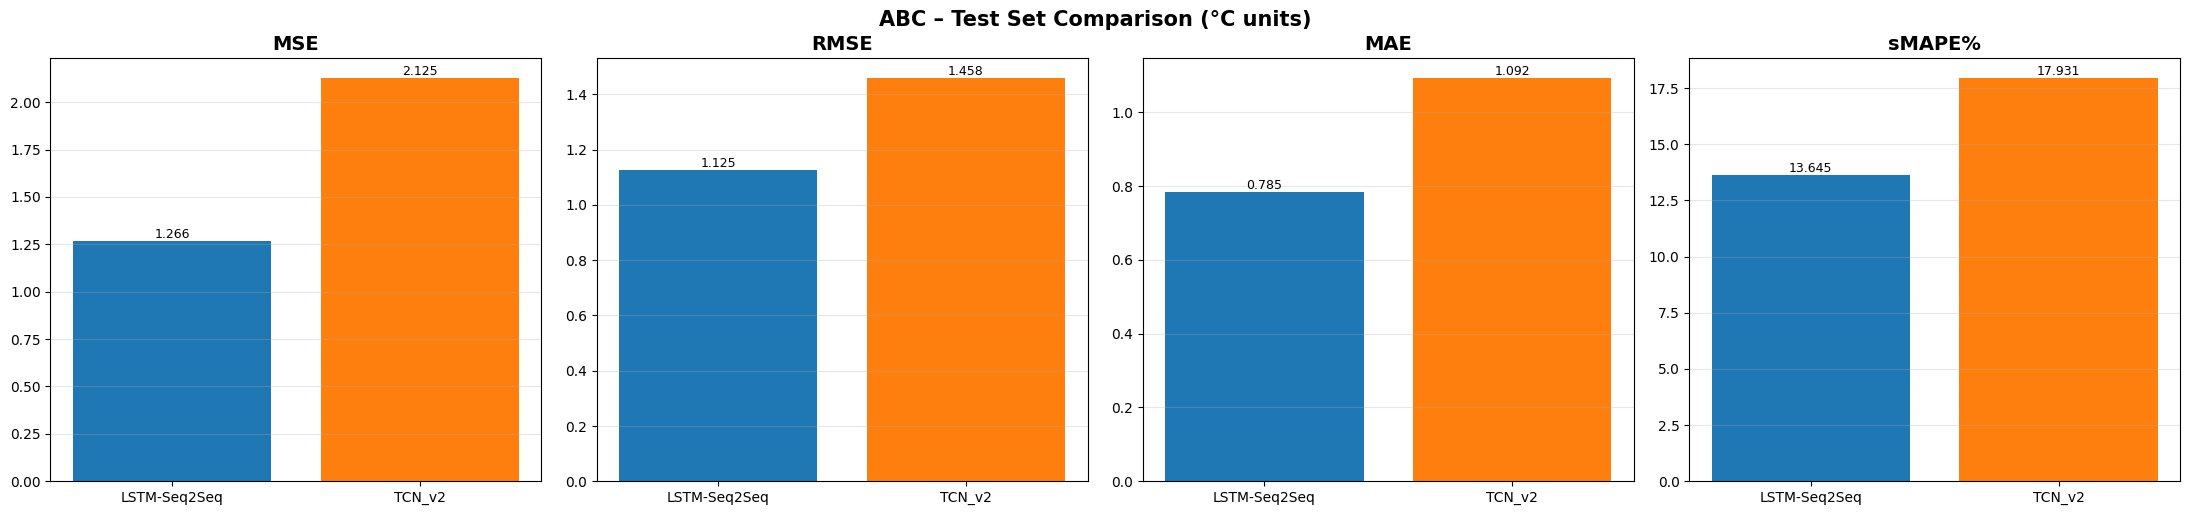


🏆 Best: LSTM-Seq2Seq | MSE=1.2656°C² | RMSE=1.1250°C


In [ ]:
# ═══════════════════════════════════════════════════════════════
# BAR CHART
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
names = ['LSTM-Seq2Seq', 'TCN_v2']
colors = ['#1f77b4', '#ff7f0e']
for ax, metric in zip(axes, ['MSE', 'RMSE', 'MAE', 'sMAPE%']):
    vals = [seq2seq_m[metric], tcn_m[metric]]
    bars = ax.bar(names, vals, color=colors)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.suptitle('ABC – Test Set Comparison (°C units)', fontsize=15, fontweight='bold', y=1.02)
plt.savefig('.../results/comparison_v9.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🏆 Best: {best_name} | MSE={best_mse:.4f}°C² | RMSE={np.sqrt(best_mse):.4f}°C')

## 10. 1-Step-AutoRegressive inference (Hướng phát triển mới để giải quyết bài toán)
**Sử dụng cơ chế dự đoán 1-Step không phải 24 bước giúp mô hình dự đoán tốt hơn**

Seq2Seq 1-Step Eval:


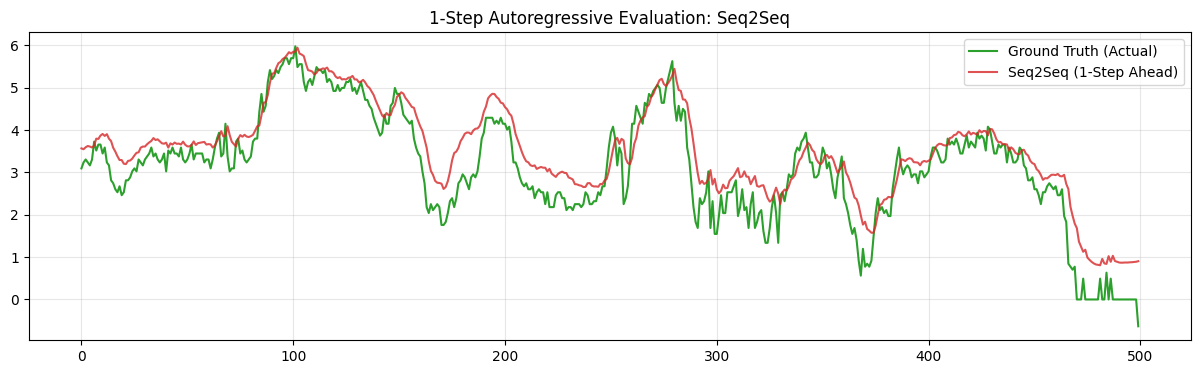

TCN 1-Step Eval:


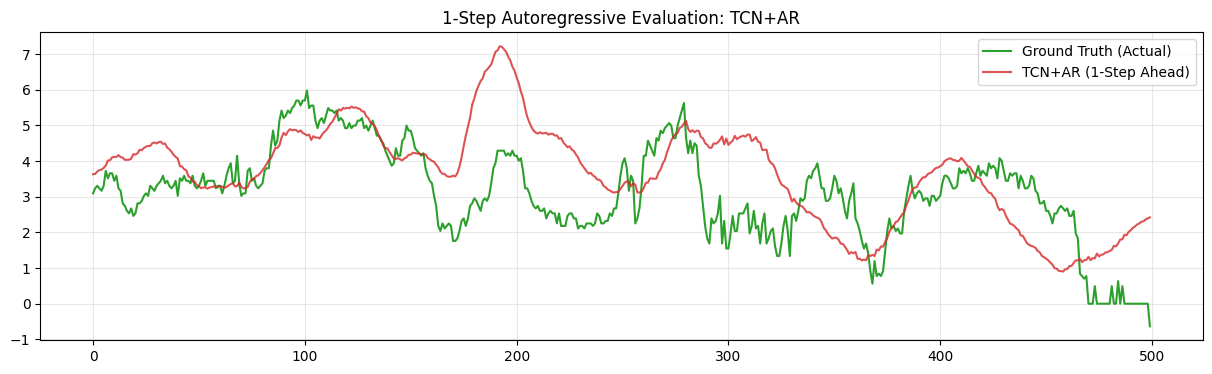

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 1-STEP AUTOREGRESSIVE EVALUATION (To replicate Paper's tight fit)
# ═══════════════════════════════════════════════════════════════
def plot_1step_autoregressive(model, model_name, dataloader, pred_func):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, Y in dataloader:
            X = X.to(device)
            Y = Y.to(device)
            # Predict 24 steps but ONLY KEEP THE FIRST STEP
            out = pred_func(model, X, Y)
            preds.append(out[:, 0].cpu().numpy())
            trues.append(Y[:, -pred_len, target_index].cpu().numpy())

    preds = np.concatenate(preds)
    trues = np.concatenate(trues)

    preds_inv = inverse_target(preds, scaler, target_index)
    trues_inv = inverse_target(trues, scaler, target_index)

    plt.figure(figsize=(15, 4))
    start_idx = 1000
    plot_len = 500
    plt.plot(trues_inv[start_idx:start_idx+plot_len], label='Ground Truth (Actual)', color='#2ca02c')
    plt.plot(preds_inv[start_idx:start_idx+plot_len], label=f'{model_name} (1-Step Ahead)', color='#d62728', alpha=0.8)
    plt.title(f'1-Step Autoregressive Evaluation: {model_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print('Seq2Seq 1-Step Eval:')
plot_1step_autoregressive(seq2seq_model, 'Seq2Seq', test_loader, seq2seq_pred_fn)

print('TCN 1-Step Eval:')
plot_1step_autoregressive(tcn_model, 'TCN+AR', test_loader, tcn_pred_fn)
